<a href="https://colab.research.google.com/github/i-suhas/DATA-SCIENCE/blob/ASD-detection/averaging_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The function does predictions on all images in a specified directory (sdir) and prints out the results.  
It has two modes of operation. In the non_averaging mode a seperate prediction is made for each image   
and the predicted class and probability is printed out for each image.  
In the averaging mode a prediction is made on each image and the probabilities are stored.  
When the predictions for all images are completed the probabilites are summed for each class.    
The class having the highest probability sum is then select as the predicted class for all images.  
The predicted class and its averaged probability is printed out  
Lets say you have 10 images of the face of the same child and you want to get a prediction if the child is autistic.    
You can get 10 individual prediction and look at each prediction. However you will get a much higher confidence    
prediction using the predictor in the averaging mode for the 10 images. Of course you can just predict on one image of a childs face  
but you get a much higher confidence if you use multiple facial images of the child and use the predictor in the averaging mode.
  
 The parameters in the function are:   
  * model_path is the  full path to the trained model
  * txt_path is the full path to the classes.txt file generated by the autism.ipynb notebook when it is run to produce the trained model.    
      The classes.txt file is of the form class0, class1, ...classN. For the case of the autistic dataset the file appears as  
      autistic,non_autistic.
  * img_size is a tupple (height, width) representing the image shape used to train the model   
  * mode is a string. If mode=='ave' the predictor provides a single prediction of the class and class probability. If mode is any    
      other string value the predictor provides an individual prediction for each image and returns a dataframe with columns  
      filename, class, probability. Each row of the dataframe contain the image file name, the class predicted and the probability    
      of the prediction.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
import numpy as np

In [3]:
def predictor(sdir, model_path, txt_path, img_size,  mode):
    with open(txt_path, 'r') as f:
        content=f.read()
    split=content.split(',')
    classes=[split[i] for i in range(len(split))]
    num_classes=len(classes)
    print("Loading the model. This may take several seconds")
    model = tf.keras.models.load_model(model_path)
    print ('model is loaded')
    flist=sorted(os.listdir(sdir))
    print ('predicting the class of the ', len(flist), ' files in ', sdir)
    filepaths=[]
    sum_list=[0 for i in range( num_classes )]
    for i, f in enumerate(flist):
        fpath=os.path.join(sdir,f)
        filepaths.append(fpath)
    Fseries=pd.Series(filepaths, name ='filepaths')
    df=pd.concat([Fseries], axis=1)
    gen=tf.keras.preprocessing.image.ImageDataGenerator().flow_from_dataframe(df, x_col='filepaths', y_col=None, target_size=img_size, class_mode=None, shuffle=False)
    preds=model.predict(gen)
    cclass=[] # list of predicted classes
    pclass=[] # list of class probabilities
    for i, p in enumerate(preds):   #iterate through the predictions
        for  j, cp in enumerate(p): # update the sum_list by adding in the probabilities of each class
            sum_list[j] +=cp
        index=np.argmax(p) # find the index of the value in p that has the highest probability
        klass=classes[index] # get the class with the highest probability
        cclass.append(klass)
        pclass.append(p[index]* 100)
    Pseries=pd.Series(pclass, name='% Probability')
    Cseries=pd.Series(cclass, name='Predicted Class')
    Fseries=pd.Series(flist, name='Filename')
    pdf=pd.concat([Fseries, Cseries, Pseries], axis=1)  # dataframe of the form Filename, Predicted Class, % Probability
    ave_index=np.argmax(sum_list)
    ave_class=classes[ave_index]
    ave_p=sum_list[ave_index]* 100/len(flist)
    if mode == 'ave':
        print (f'The class prediction for all images is {ave_class} with a probability of {ave_p:6.2f} %')
        return ave_class, ave_p
    else:
        print (pdf)
        return pdf


## Load and preprocess data

### Subtask:
Load the train, test, and validation image datasets from the specified folder and preprocess them for the model.


**Reasoning**:
Define the paths and image size, then create and configure the image data generators for training, validation, and testing using `ImageDataGenerator` and `flow_from_directory`.



In [5]:
train_dir = r'/content/drive/MyDrive/ASD-COLAB/autism/train'
validation_dir = r'/content/drive/MyDrive/ASD-COLAB/autism/valid'
test_dir = r'/content/drive/MyDrive/ASD-COLAB/autism/test'

# Image size is already defined as img_size = (200, 200)
img_size = (200, 200)

# Create data generators
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Load images from directories using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='binary',
    shuffle=False) # Keep data in order for evaluation

Found 2526 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


## Define and compile the model

### Subtask:
Define a suitable machine learning model architecture and compile it with an appropriate optimizer, loss function, and metrics.


**Reasoning**:
Import necessary layers and define and compile the sequential model with convolutional, pooling, flatten, and dense layers.



In [6]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = tf.keras.models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train the model

### Subtask:
Train the defined model using the training data and validate it using the validation data.


**Reasoning**:
Train the compiled Keras model using the training and validation data generators for a specified number of epochs and store the training history.



In [7]:
epochs = 10
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5037 - loss: 1.3532

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


79/79 ━━━━━━━━━━━━━━━━━━━━ 557s 7s/step - accuracy: 0.5043 - loss: 1.3469 - val_accuracy: 0.6400 - val_loss: 0.6463
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6586 - loss: 0.6385 - val_accuracy: 0.6200 - val_loss: 0.6306
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 307s 4s/step - accuracy: 0.6632 - loss: 0.6191 - val_accuracy: 0.6700 - val_loss: 0.6202
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 314s 4s/step - accuracy: 0.6841 - loss: 0.5977 - val_accuracy: 0.6950 - val_loss: 0.6055
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 307s 4s/step - accuracy: 0.7265 - loss: 0.5523 - val_accuracy: 0.6100 - val_loss: 0.7260
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step - accuracy: 0.7271 - loss: 0.5403 - val_accuracy: 0.6900 - val_loss: 0.6041
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.7356 - loss: 0.5265 - val_accuracy: 0.7200 - val_loss: 0.5768
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.7567 - loss: 0.4989 - val_accuracy: 0.7200 - val_loss: 0.

**Reasoning**:
Continue training the model for the remaining epochs.



## Evaluate the model

### Subtask:
Evaluate the trained model's performance on the test data.

**Reasoning**:
Evaluate the trained model on the test dataset using the `evaluate` method and print the test loss and accuracy.

In [8]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.8105 - loss: 0.4761
Test Loss: 0.3913
Test Accuracy: 0.8500


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Sample Predictions:


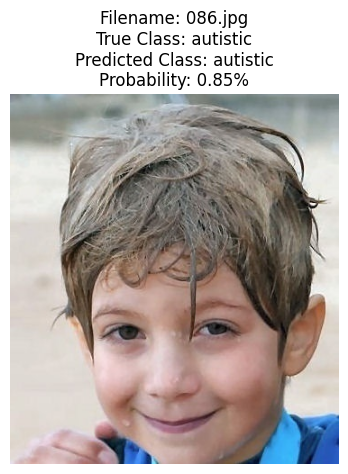

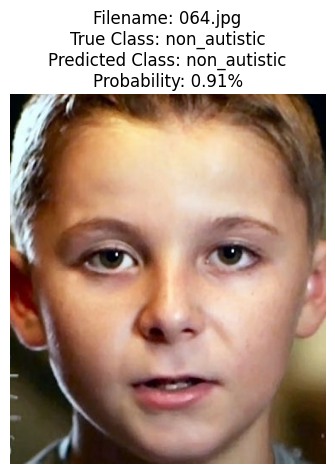

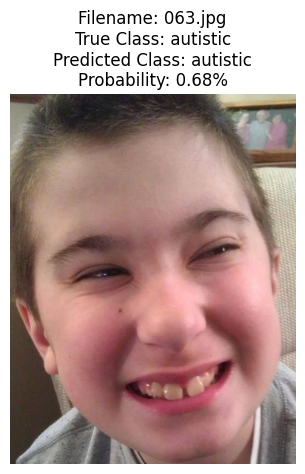

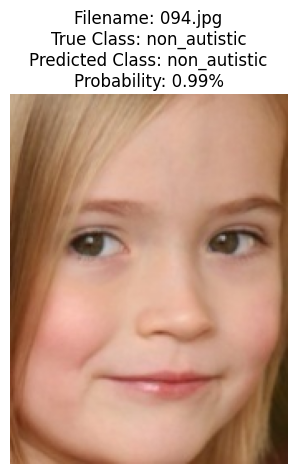

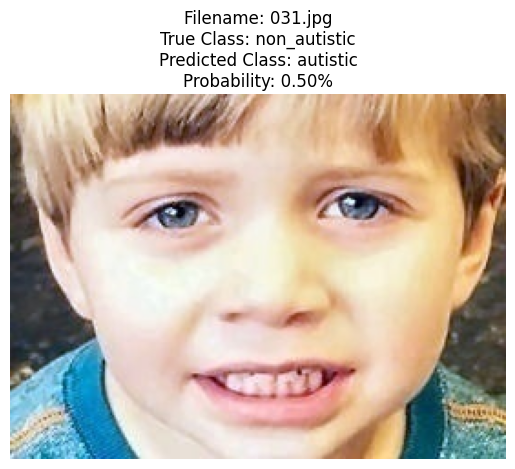

In [10]:
# Get predictions for the test set
test_generator.reset() # Reset the generator to ensure order
predictions = model.predict(test_generator)

# Get the true labels
true_labels = test_generator.classes

# Get the filenames
filenames = [f.split('/')[-1] for f in test_generator.filenames]

# Create a DataFrame to display results
results_df = pd.DataFrame({'filename': filenames, 'true_label': true_labels, 'prediction': predictions.flatten()})

# Add predicted class and probability
results_df['predicted_class'] = results_df['prediction'].apply(lambda x: 'non_autistic' if x > 0.5 else 'autistic')
results_df['probability'] = results_df['prediction'].apply(lambda x: x if x > 0.5 else 1 - x)

# Map true labels to class names
class_indices = test_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
results_df['true_class'] = results_df['true_label'].map(idx_to_class)

# Display some sample predictions with images
print("Sample Predictions:")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Select a few random samples to display
sample_indices = np.random.choice(len(results_df), size=5, replace=False)

for i in sample_indices:
    filename = results_df.loc[i, 'filename']
    predicted_class = results_df.loc[i, 'predicted_class']
    probability = results_df.loc[i, 'probability']
    true_class = results_df.loc[i, 'true_class']
    filepath = os.path.join(test_dir, true_class, filename) # Construct the full file path

    img = mpimg.imread(filepath)
    plt.imshow(img)
    plt.title(f"Filename: {filename}\nTrue Class: {true_class}\nPredicted Class: {predicted_class}\nProbability: {probability:.2f}%")
    plt.axis('off')
    plt.show()

## Technical Stack Overview

This project utilizes the following technical stack:

*   **Python**: The primary programming language used for data loading, preprocessing, model definition, training, and evaluation.
*   **TensorFlow**: A powerful open-source machine learning library used for building and training the convolutional neural network (CNN) model.
*   **Keras**: A high-level API for building and training deep learning models, running on top of TensorFlow. It simplifies the process of defining and training neural networks.
*   **NumPy**: A fundamental library for numerical computing in Python, used for array manipulation and calculations.
*   **Pandas**: A data manipulation and analysis library, used for handling the dataset, organizing results, and creating DataFrames.
*   **Matplotlib**: A plotting library used for visualizing sample predictions and images.
*   **Google Colab**: The cloud-based platform providing the environment for running the notebook, including access to GPUs for faster training.
*   **Google Drive**: Used for storing the dataset and the trained model.